<style>
  .jp-RenderedImage,
  .jp-RenderedSVG {
    text-align: center;
  }

  .jp-RenderedImage img,
  .jp-RenderedSVG svg {
    display: block;
    margin-left: auto;
    margin-right: auto;
  }
</style>

I remember first discovering the amazing [Deep Implicit Layers tutorial](https://implicit-layers-tutorial.org/) by Zico Kolter, David Duvenaud, and Matt Johnson around 2021. I was trying to understand how neural networks could be used to learn dynamical systems from data (e.g. Neural ODEs), which to be honest, was quite novel to me. I was so used to thinking of neural networks as learning a function $NN(x;\theta)\approx f(x)$ that it never occurred to me that one could instead do $\frac{dx}{dt}=f(x)\approx NN(x;\theta)$. It looks like a small change, but it took me a while to wrap my head around that concept. 

Even more interesting to me was realizing that neural ODEs were just one instance of a broader class of models: implicit layers. Broadly speaking, the idea is that instead of learning the input-output map directly, you learn something that defines the map indirectly. That is, the output of a layer is defined not by a direct formula, but as the result of solving some underlying problem: following dynamics, finding a fixed point, minimizing an objective, or satisfying a constraint.

<div style="max-width: 80%; margin: 1.5rem auto 2rem auto; text-align: center;">
    <img
      src="{{ '/assets/img/tiny-convex-layer/zico-kolter-implicit-layer-slide.png' | relative_url }}"
      alt="Zico Kolter implicit layers tutorial slide"
      style="display: block; width: 100%; height: auto; margin: 0 auto; border-radius: 0.25rem;"
      loading="lazy"
    />
    <div class="caption" style="margin-top: 0.5rem; color: #808080; font-size: 0.875rem; line-height: 1.35; text-align: center;">
      Screenshot from Zico Kolter's implicit layers tutorial.
    </div>
</div>

In many cases, this means **putting a solver inside the model**. The layer then receives some inputs, solves an underlying problem, and returns the solution as its output. From the perspective of a neural network, this is just another layer with a forward pass. The tricky part is the backward pass: how do we propagate gradients through a solution that was obtained by running a solver?

This is very powerful because it gives us a general way to build layers defined through solvers, without manually deriving and implementing each case from scratch. In practice, one can often use these ideas without fully understanding all the machinery behind them. But learning how they work behind the scenes requires a fair amount of mathematics, which can make the topic feel intimidating at first.

Since I have recently been diving much deeper into these topics, I thought it would be useful to write a tutorial series that starts from the simplest example I can think of and builds up from there. The goal is to introduce some of the machinery behind implicit layers in a way that makes concepts like Lagrangians, KKT conditions, and implicit differentiation feel more intuitive (or at least more intuitive for me, and I hope for you as well!).

For this part I, I will start with a simple idea: a model gives a raw prediction, an optimizer turns it into the closest prediction that satisfies a rule, and training can learn the rule by looking at how the optimizer’s solution changes.

## A simple motivating problem

Let's start with a very simple problem:

$$
z^\star(c)
=
\arg\min_z \frac{1}{2}\|z-r\|_2^2
\quad \text{s.t.} \quad z_1+z_2=c
$$

This reads: given a point $r$, find $z^\star(c)$, the closest point to a given $r$ (minimizing the Euclidean distance), whose two coordinates add up to $c$. For example, let's say the given point is $r=(3.4,0.2)$, and $c=2$. This point is not *feasible*, since $r_1+r_2=3.6\neq 2$. We need to find the point $z^\star=(z^\star_1, z^\star_2)$ that is as close as possible to $r$, while satisfying the constraint $z^\star_1 + z^\star_2 = 2$.

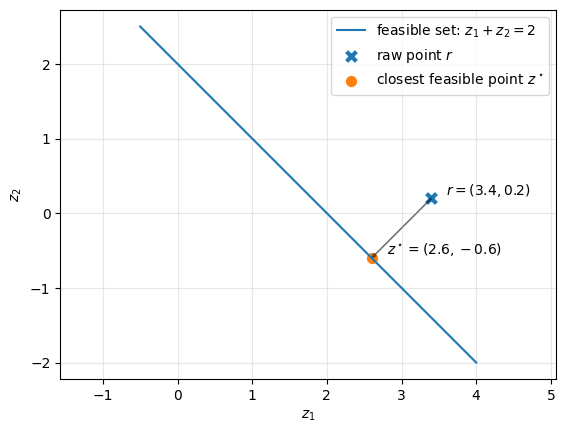

In [6]:
import numpy as np
import matplotlib.pyplot as plt

r = np.array([3.4, 0.2])
# closest point satisfying z1 + z2 = 2
z_star = np.array([2.6, -0.6])

x = np.linspace(-0.5, 4.0, 200)
y = 2 - x

plt.plot(x, y, label=r"feasible set: $z_1 + z_2 = 2$")
plt.scatter(*r, marker="x", s=50, linewidths=3, label=r"raw point $r$")
plt.scatter(*z_star, s=50, label=r"closest feasible point $z^\star$")

plt.arrow(
    r[0], r[1],
    z_star[0] - r[0],
    z_star[1] - r[1],
    length_includes_head=True,
    head_width=0.04,
    alpha=0.5
)

plt.text(3.60, 0.25, r"$r=(3.4,0.2)$")
plt.text(2.80, -0.55, r"$z^\star=(2.6,-0.6)$")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel(r"$z_1$")
plt.ylabel(r"$z_2$")
plt.legend();

This is basically a projection. Among all points on the line $z_1+z_2=c$, it selects the one closest to $r$. In this example, the Euclidean distance between $r=(3.4, 0.2)$ and the optimal projection $z^\star=(2.6, -0.6)$ is $\sqrt{0.8^2 + 0.8^2} \approx 1.13$. The optimization objective uses the half-squared distance, so its value at the optimum is $\frac12\|z^\star-r\|_2^2 = 0.64$.

Now, the question is: can we learn some parameters of this optimization problem, like c, in a data-driven manner? We're not just interested in solving an optimization problem: we want to learn the parameters of the optimization problem so that we can use the output of the solver itself to compute a loss. Something like this:

$$
x
\;\longrightarrow\;
\boxed{\mathrm{NN}_\theta(x)}
\;\longrightarrow\;
r
\;\longrightarrow\;
\boxed{
\begin{array}{c}
\text{optimization layer} \\[6pt]
\begin{aligned}
z^\star(c)
&=
\arg\min_z \quad \frac12\|z-r\|_2^2 \\
&\phantom{=\,\arg\min_z \quad}\text{s.t.}\quad z_1+z_2=c
\end{aligned}
\end{array}
}
\;\longrightarrow\;
z^\star(c)
\;\longrightarrow\;
\mathcal{L}(z^\star(c),y)
$$

Now, using our ground truth constraint, let's generate some noisy dataset:

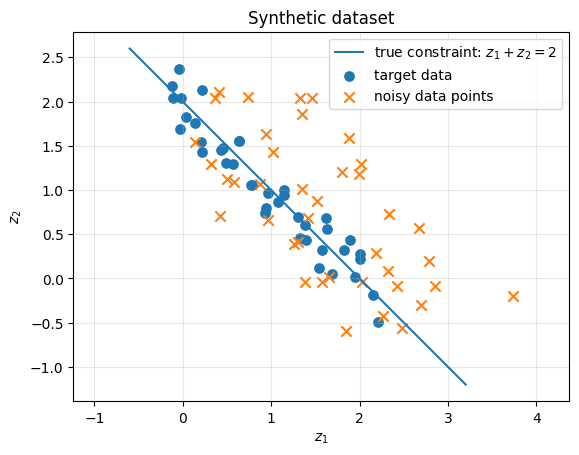

In [7]:
import numpy as np

np.random.seed(42)

n = 40
c_true = 2.0

# Create points near the *hidden* constraint line z1 + z2 = 2
z1 = np.linspace(-0.2, 2.2, n)
z2 = c_true - z1

# Ground truth points to predict (y)
y_clean = np.column_stack([z1, z2])
# Noisy predictions
y = y_clean + 0.15 * np.random.randn(n, 2)

# Raw points (data) with noise and bias
r = y + np.array([0.65, -0.25]) + 0.5 * np.random.randn(n, 2)

# Plot
x = np.linspace(-0.6, 3.2, 200)
line = c_true - x

plt.plot(x, line, label=r"true constraint: $z_1 + z_2 = 2$")
plt.scatter(y[:, 0], y[:, 1], s=45, label="target data")
plt.scatter(r[:, 0], r[:, 1], marker="x", s=55, label="noisy data points")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel(r"$z_1$")
plt.ylabel(r"$z_2$")
plt.title("Synthetic dataset")
plt.legend();

<div style="margin: 1.5rem 0; padding: 1rem 1.25rem; border-left: 4px solid #b8b8b8; background: rgba(128, 128, 128, 0.08); border-radius: 0.25rem;">
  <strong style="display: block; margin-bottom: 0.35rem;">Note:</strong>
  
  This toy problem is deliberately almost too simple. The projection has a closed-form formula, and if the only unknown is the constant $c$, we could estimate it directly from the targets. We do not need a solver for this specific case.

  But that simplicity is useful. Because the answer is easy to check, we can focus on the mechanism: how a constrained optimization problem becomes a solver, and how gradients can flow through its solution. Later, we will move to more interesting cases where the constraint is not just $z_1 + z_2 = c$, but something input-dependent, like $z_1 + z_2 = f_{\theta}(x)$ where $f_{\theta}$ can be non-linear. That is where the same machinery start to become more useful.

</div>

Ok, we have a dataset now. We could discover the value of $c$ by just fitting a line through the blue target points, as you can see in the plot above, so the problem is trivial. However, we are going to learn $c$ in a more indirect way (implicitly): as the constraint line onto which we project the noisy data points, shown as orange crosses.

## Getting rid of the constraint with penalties

What makes this problem different from the optimization problems we usually see in machine learning is the constraint. If you have trained neural networks before, you are probably used to unconstrained optimization: define a loss, compute gradients, and update the parameters. The optimizer is allowed to search anywhere in parameter space.

Here, the variable $z$ is not allowed to take any value, it must satisfy $z_1 + z_2 = c$. Without this constraint, the problem is even simpler, since the closest point to $r$ is just $r$ itself.

So the first step is to ask whether we can transform this constrained problem into something we already know how to solve easily: an unconstrained problem. One natural idea is to keep the original objective, but add a term that punishes violations of the constraint.

$$
\arg\min_z \frac{1}{2}\|z-r\|_2^2
\quad \text{s.t.} \quad z_1+z_2=c
$$

We can create a term that checks the magnitude of the violation. The constraint says $z_1+z_2-c = 0$. So, if $z_1+z_2-c$ is different from zero, we penalize it in proportion to the magnitude of the violation:
$$
\arg\min_z \frac{1}{2}\|z-r\|_2^2 + \rho(z_1+z_2-c)^2
$$

The larger $\rho$ is, the more expensive it becomes to violate the constraint.

Did we solve the problem? Not yet. This penalizes constraint violations, but it does not guarantee that the constraint is satisfied exactly. For finite $\rho$, small violations are still allowed. To strictly enforce the constraint, we would need $\rho \to \infty$, but then the penalty term dominates the objective and the problem becomes numerically awkward.

Let's visualize that to make this concept clear. We will use a simple grid search:

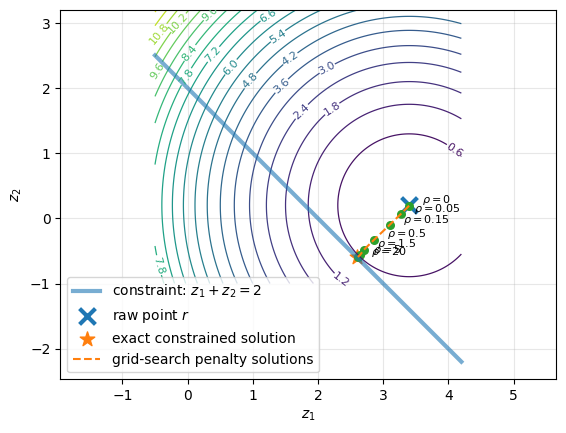

In [8]:
r = np.array([3.4, 0.2])
c = 2.0

# Candidate points z = (z1, z2)
z1 = np.linspace(-0.5, 4.2, 300)
z2 = np.linspace(-1.0, 3.2, 300)
Z1, Z2 = np.meshgrid(z1, z2)

# Original objective and constraint violation
distance = 0.5 * ((Z1 - r[0])**2 + (Z2 - r[1])**2)
violation = Z1 + Z2 - c

# Exact constrained solution, only for visual reference
z_exact = np.array([2.6, -0.6])

# Values of rho used for the geometry plot
rhos_for_plot = np.array([0, 0.05, 0.15, 0.5, 1.5, 5, 20])

# Values of rho used for the curve plot
rhos_for_curve = np.logspace(-3, 2, 100)


def solve_by_grid_search(rho):
    objective = distance + rho * violation**2

    row, col = np.unravel_index(
        np.argmin(objective),
        objective.shape
    )

    z = np.array([Z1[row, col], Z2[row, col]])
    d = distance[row, col]
    v = violation[row, col]
    p = rho * v**2

    return z, d, v, p


# Compute solutions for selected rho values
solutions = np.array([
    solve_by_grid_search(rho)[0]
    for rho in rhos_for_plot
])

# Compute curves for many rho values
curve_data = np.array([
    solve_by_grid_search(rho)[1:]
    for rho in rhos_for_curve
])

distance_terms = curve_data[:, 0]
violations = np.abs(curve_data[:, 1])
penalty_terms = curve_data[:, 2]


# Contours of the original distance objective
contours = plt.contour(Z1, Z2, distance, levels=20, linewidths=0.9)
plt.clabel(contours, inline=True, fontsize=8)

# Feasible line z1 + z2 = c
line_x = np.linspace(-0.5, 4.2, 300)
plt.plot(
    line_x,
    c - line_x,
    linewidth=3,
    alpha=0.6,
    label=r"constraint: $z_1+z_2=2$"
)

# Raw point and exact constrained solution
plt.scatter(
    r[0], r[1],
    s=130,
    marker="x",
    linewidths=3,
    label=r"raw point $r$"
)

plt.scatter(
    z_exact[0], z_exact[1],
    s=120,
    marker="*",
    label=r"exact constrained solution"
)

# Penalty solutions
plt.plot(
    solutions[:, 0],
    solutions[:, 1],
    "--",
    linewidth=1.5,
    label=r"grid-search penalty solutions"
)

plt.scatter(solutions[:, 0], solutions[:, 1], s=30)

for rho, z in zip(rhos_for_plot, solutions):
    plt.text(
        z[0] + 0.20,
        z[1] + 0.04,
        fr"$\rho={rho:g}$",
        fontsize=8
    )

plt.xlabel(r"$z_1$")
plt.ylabel(r"$z_2$")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left");

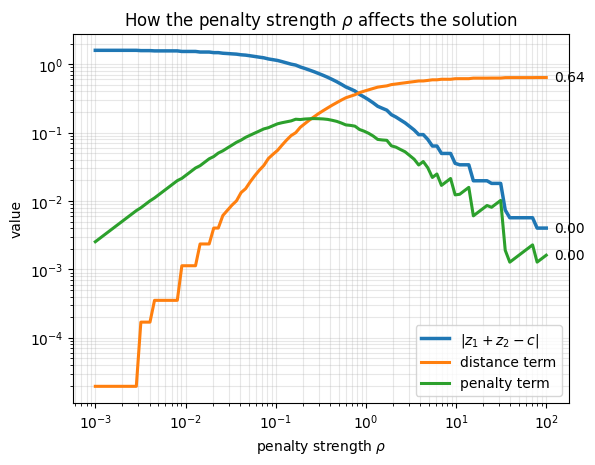

In [9]:
plt.loglog(
    rhos_for_curve,
    violations,
    linewidth=2.5,
    label=r"$|z_1+z_2-c|$"
)

plt.loglog(
    rhos_for_curve,
    distance_terms,
    linewidth=2.2,
    label=r"distance term"
)

plt.loglog(
    rhos_for_curve,
    penalty_terms,
    linewidth=2.2,
    label=r"penalty term"
)

# Add final-value labels
for y, name in [
    (violations, r"$|z_1+z_2-c|$"),
    (distance_terms, "distance"),
    (penalty_terms, "penalty"),
]:
    plt.annotate(
        f"{y[-1]:.2f}",
        xy=(rhos_for_curve[-1], y[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
    )

plt.xlabel(r"penalty strength $\rho$")
plt.ylabel("value")
plt.title(r"How the penalty strength $\rho$ affects the solution")
plt.grid(True, alpha=0.3, which="both")
plt.legend();

As $\rho$ increases, the penalty solution moves toward the constrained projection $z^\star=(2.6,-0.6)$, approaching the optimal distance term:

$$
\frac12\|z^\star-r\|_2^2
= \frac12\left((2.6-3.4)^2 + (-0.6-0.2)^2\right)
= \frac12\left(0.8^2 + 0.8^2\right)
= 0.64.
$$

In this toy example, we see how the penalized solution moves toward the constrained optimum. However, the penalty method does not enforce the constraint exactly for any finite value of $\rho$. It only makes violations of the constraint increasingly expensive.

Here, increasing $\rho$ pushes the solution very close to the true constrained projection, so the violation becomes visually negligible. But visually negligible is not the same as exactly feasible.

In general, to make the violation go to zero, we would need to take $\rho \to \infty$. At that point, the penalty term dominates the original objective, and the optimization problem becomes increasingly ill-conditioned.


## From penalties to exact constraints

So far, we have treated the constraint as something to punish. That is useful, but it is also a quick-and-dirty solution. We are not really solving the original constrained problem; we are solving a different problem that approximates it by penalizing infeasibility.

The penalty method added a squared cost for violating the constraint. For our toy constraint,

$$
z_1 + z_2 = c,
$$

the violation is

$$
z_1 + z_2 - c.
$$

So the penalty version was:

$$
\|z-r\|_2^2
+
\rho(z_1+z_2-c)^2.
$$

This made violations expensive, but it still allowed them.

Now let’s change the idea slightly. Instead of adding a squared penalty, we add a linear term in the violation:

$$
\|z-r\|_2^2
+
\lambda(z_1+z_2-c).
$$

For any fixed value of $\lambda$, this is still just an unconstrained optimization problem in $z$.

The difference is that this new term **behaves differently** from the squared penalty. The squared penalty only cares about the size of the violation. If the violation is positive or negative, it does not matter; once we square it, both sides are punished the same way. **The linear term keeps the sign of the violation**. Depending on the value of $\lambda$, it can push the solution in one direction or the other. So instead of making violations more and more expensive, we can now ask a different question:

Can we choose $\lambda$ so that the minimizer of this unconstrained problem lands exactly on the constraint?

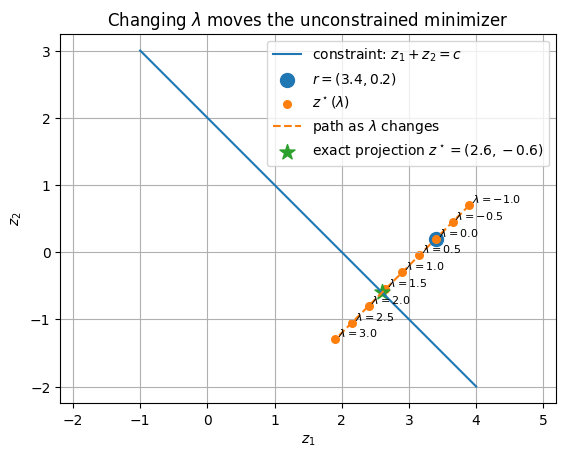

In [12]:
# Original example
r = np.array([3.4, 0.2])
c = 2.0

# Constraint: z1 + z2 = c
x = np.linspace(-1.0, 4.0, 200)
y = c - x

lambdas = np.linspace(-1.0, 3.0, 9)

solutions = np.array([
    r - (lam / 2) * np.array([1.0, 1.0])
    for lam in lambdas
])

# Exact lambda that makes z*(lambda) feasible:
# z1 + z2 = c
# r1 + r2 - lambda = c
# lambda = r1 + r2 - c
lambda_star = r.sum() - c
z_star = r - (lambda_star / 2) * np.array([1.0, 1.0])

plt.plot(x, y, label=r"constraint: $z_1 + z_2 = c$")
plt.scatter(r[0], r[1], s=100, label=r"$r=(3.4,0.2)$")
plt.scatter(solutions[:, 0], solutions[:, 1], s=30, label=r"$z^\star(\lambda)$")
plt.plot(
    solutions[:, 0],
    solutions[:, 1],
    linestyle="--",
    label=r"path as $\lambda$ changes"
)
plt.scatter(
    z_star[0],
    z_star[1],
    s=130,
    marker="*",
    label=rf"exact projection $z^\star=({z_star[0]:.1f},{z_star[1]:.1f})$"
)

for lam, z in zip(lambdas, solutions):
    plt.text(z[0] + 0.04, z[1] + 0.04, rf"$\lambda={lam:.1f}$", fontsize=8)

plt.axis("equal")
plt.xlabel(r"$z_1$")
plt.ylabel(r"$z_2$")
plt.title(r"Changing $\lambda$ moves the unconstrained minimizer")
plt.legend()
plt.grid(True);

As you can see, as we increase the value of $\lambda$, there is a moment at which we *cross* the line. So there should be a value of $\lambda$ for which $z^\star(\lambda)$ lands directly on the line, and thus we **exactly** satisfy the constraint $z_1 + z_2 = c$.

So let’s define the new objective directly in terms of our toy constraint, including the value of $\lambda$:

$$
\mathcal{L}(z,\lambda)
=
\|z-r\|_2^2
+
\lambda(z_1+z_2-c)
$$

To make the notation more compact and general, we can replace $z_1 + z_2$ with vector notation:

$$
z =
\begin{bmatrix}
z_1 \\
z_2
\end{bmatrix},
\quad
A =
\begin{bmatrix}
1 \\
1
\end{bmatrix}.
$$

Then

$$
A^\top z =
\begin{bmatrix} 1 & 1 \end{bmatrix}
\begin{bmatrix}
z_1 \\
z_2
\end{bmatrix}
= z_1 + z_2.
$$

So we have the same thing, but more compact now:

$$
\mathcal{L}(z,\lambda)
=
\|z-r\|_2^2
+
\lambda(A^\top z-c).
$$

But now that the objective also depends on $\lambda$, we make explicit that the minimizer with respect to $z$ depends on the chosen value of $\lambda$. So for each fixed $\lambda$, we write

$$
z^\star(\lambda)
=
\arg\min_z \mathcal L(z,\lambda).
$$

This is what we represented in the plot above: for each $\lambda$, we have a $z^\star$ (orange dot), and there is one that lands exactly on the line. We need to find that $\lambda$!

## The Lagrangian

This augmented objective $\mathcal{L}(z,\lambda)$ has a name: it is the **Lagrangian** of the constrained problem.

The path to get here was simple: we first moved the constraint into the objective using a quadratic penalty. That gave us an unconstrained problem, but only an approximate solution. Then we replaced the quadratic penalty with a linear term, which keeps the sign of the violation and lets $\lambda$ control how the constraint pushes on the minimizer.

In our example, this push has a very concrete effect: as $\lambda$ changes, the minimizer crosses the constraint line, as shown in the previous plot. So now we are not looking for an infinitely large penalty; we are looking for the right value of $\lambda$, the one that makes the minimizer satisfy the constraint exactly.

So let’s find this value. First, we need a function that tells us, for any fixed $\lambda$, where the best $z$ is. In other words, we want to compute $z^\star(\lambda)$.

For a fixed $\lambda$, the objective is just an unconstrained function of $z$:

$$
\mathcal{L}(z,\lambda)
=
\|z-r\|_2^2
+
\lambda(A^\top z-c).
$$

To find the value of $z$ that minimizes it, we use the usual rule for smooth unconstrained problems: at the minimum, the gradient with respect to $z$ should be zero.

Taking the gradient with respect to $z$ gives:

$$
\nabla_z \mathcal{L}(z,\lambda)
=
2(z-r) + \lambda A.
$$

At the minimizer, this gradient must be zero:

$$
2(z-r) + \lambda A = 0.
$$

Solving for $z$:

$$
z = r - \frac{\lambda}{2}A.
$$

So for each value of $\lambda$, the unconstrained minimizer is

$$
z^\star(\lambda)
=
r - \frac{\lambda}{2}A.
$$



We can check, e.g. as in the plot, for $\lambda=1$ and for $r=(3.4, 0.2)$, we have:

$$
z^\star(1)
=
r-\frac{1}{2}A
=
\begin{bmatrix}
3.4 \\
0.2
\end{bmatrix}
-
\frac{1}{2}
\begin{bmatrix}
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
3.4 \\
0.2
\end{bmatrix}
-
\begin{bmatrix}
0.5 \\
0.5
\end{bmatrix}
=
\begin{bmatrix}
2.9 \\
-0.3
\end{bmatrix}.
$$